NYC TLC YELLOW TAXI TRIP DURATION ANALYSIS

Name - Gurnoor Singh 

Student ID - s223955119 

Email - s223955119@deakin.edu.au

Unit - SIT 220 (Undergraduate)

INTRODUCTION

In this report, we analyse Yellow taxi trip records from NYC Taxi and Limousine Commission(TLC) dataset for January, February and March 2026. The goal is to build a pandas-based predictive pipeline that estimates trip duration while coverinng data cleaning, feature engineering and predictive modelling. 

Importing required libraries 

In [4]:
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


DATA ACQUISATION AND SCOPE 

Acquisation and scope justification in written report. 

Loading selected datasets. 

In [7]:
#dataset for jan 2026
df1 = pd.read_parquet("C:/Users/gurno/Downloads/sit220HDdatasets/janyellow_tripdata_2026-01.parquet")

#dataset for feb 2026
df2 = pd.read_parquet("C:/Users/gurno/Downloads/sit220HDdatasets/febyellow_tripdata_2026-02.parquet")

#dataset for march 2026
df3 = pd.read_parquet("C:/Users/gurno/Downloads/sit220HDdatasets/marchyellow_tripdata_2026-03.parquet")

df = pd.concat([df1,df2,df3],ignore_index=True)

#number of rows and columns 
print(df.shape)

(11077206, 20)


The three monthly Parquet files are succesfully loaded and combined into a single dataframe containing 11,077,206 rows and 20 columns.

DATA WRANGLING AND PRE-PROCESSING

Inspection, validation and cleaning of dataset. 

Refer to report for details.

Identifying datatypes

In [12]:
#inspecting the dataset schema 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11077206 entries, 0 to 11077205
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee         

The dataset contains two datetime columns for pick up and dropoff times, 13 float columns covering fare related variables and one object column for store and forward flag. Memory usage is 1.5GB approx. 

Checking for null values. 

In [16]:
df.isnull().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          3057123
trip_distance                  0
RatecodeID               3057123
store_and_fwd_flag       3057123
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     3057123
Airport_fee              3057123
cbd_congestion_fee             0
dtype: int64

Interestingly, same number of values across 5 columns are null which indicates that one or more number of vendors did not report to those fields correctly.  

Checking for duplicate rows and basic stats within data 

In [20]:
print("Duplicate rows : ", df.duplicated().sum())
df.describe()

Duplicate rows :  0


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,1.107721e+07,11077206,11077206,8.020083e+06,1.107721e+07,8.020083e+06,1.107721e+07,1.107721e+07,1.107721e+07,1.107721e+07,1.107721e+07,1.107721e+07,1.107721e+07,1.107721e+07,1.107721e+07,1.107721e+07,8.020083e+06,8.020083e+06,1.107721e+07
mean,1.876552e+00,2026-02-15 16:11:28.931824,2026-02-15 16:28:54.533629,1.238929e+00,6.221664e+00,5.384528e+00,1.613870e+02,1.608872e+02,8.508780e-01,2.124950e+01,1.053296e+00,4.862019e-01,2.706643e+00,5.067500e-01,9.509915e-01,2.979328e+01,2.172388e+00,1.494923e-01,5.241209e-01
min,1.000000e+00,2008-12-31 23:03:20,2009-01-01 00:07:36,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-2.555200e+03,-7.500000e+00,-5.000000e-01,-8.888000e+01,-1.117900e+02,-1.000000e+00,-2.560200e+03,-2.500000e+00,-2.000000e+00,-7.500000e-01
25%,2.000000e+00,2026-01-24 00:02:16,2026-01-24 00:16:40,1.000000e+00,1.000000e+00,1.000000e+00,1.140000e+02,1.070000e+02,0.000000e+00,1.000000e+01,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.725000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2026-02-14 21:54:05,2026-02-14 22:12:57,1.000000e+00,1.800000e+00,1.000000e+00,1.610000e+02,1.620000e+02,1.000000e+00,1.560000e+01,0.000000e+00,5.000000e-01,2.000000e+00,0.000000e+00,1.000000e+00,2.355000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2026-03-10 14:52:12,2026-03-10 15:13:28,1.000000e+00,3.700000e+00,1.000000e+00,2.330000e+02,2.340000e+02,1.000000e+00,2.680000e+01,2.500000e+00,5.000000e-01,3.850000e+00,0.000000e+00,1.000000e+00,3.471000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2026-04-01 00:06:25,2026-04-02 16:03:47,9.000000e+00,3.285222e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,2.555200e+03,2.071000e+01,4.750000e+00,7.660000e+02,1.400000e+03,1.000000e+00,2.560200e+03,2.500000e+00,2.700000e+01,7.500000e-01
std,7.105294e-01,NaN,NaN,6.461159e-01,6.207150e+02,2.003832e+01,6.690951e+01,7.093040e+01,6.758964e-01,1.873519e+01,1.718890e+00,1.025176e-01,3.892603e+00,2.179020e+00,2.492188e-01,2.237361e+01,9.048935e-01,5.378711e-01,3.523499e-01


The dataset contains no duplicate rows. However, describe() reveals several data quality issues such as timestamps going far back to 2008, fare amounts and tips in negative, passenger count of zero and more. These invalid recoreds must be removed during cleaning stage. 

Dropping null values and filtering

A series of filters and pre-processing is applied to transform the raw dataset into analysis ready dataset, please refer to report for details. 

In [24]:
#dropping rows with nulls in key columns
df = df.dropna(subset=['passenger_count','RatecodeID','congestion_surcharge','Airport_fee'])

#filtering valid timestamps only (within 2026 Jan-Mar)
df = df[(df['tpep_pickup_datetime'] >= '2026-01-01') & (df['tpep_dropoff_datetime'] <= '2026-03-31')]

#filtering valid passenger count only 
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]

#filter valid trip distance
df = df[(df['trip_distance'] > 0) & (df['trip_distance'] <= 100)]

#filter valid fare amount
df = df[(df['fare_amount'] > 0) & (df['fare_amount'] <= 500)]

print(df.shape)

(7706274, 20)


Converting datatypes for relevant analysis

In [27]:
df['passenger_count'] = df['passenger_count'].astype(int)
df['RatecodeID'] = df['RatecodeID'].astype(int)

print(df.dtypes)
df = df.copy()

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int32
trip_distance                   float64
RatecodeID                        int32
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object


Rows with null values, out-of-range timestamps, invalid passenger counts, implausible trip distances and negative fares are removed, reducing dataset from 11,077,206 to 7,706,274 rows. The passenger_count and RatecodeID are also converted from float to integer as they represent discrete numerical variables. 

FEATURE EXTRACTION (ENGINEERING) 

New features are extracted from raw data to improve predictive power. Trip duration calculated here serves as target variable. Please refer to report for further explanation. 

In [31]:
#calculating the target variable 
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()/60

#temporal features
df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek
df['month'] = df['tpep_pickup_datetime'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_rush_hour'] = (df['hour'].isin([7,8,9,16,17,18,19])).astype(int)


#fitler invalid trip durations 
df = df[(df['trip_duration']>0) & (df['trip_duration'] <= 180)]

print(df[['trip_duration','hour','day_of_week','month','is_weekend','is_rush_hour']].describe())
print("Shape : ",df.shape)

       trip_duration          hour   day_of_week         month    is_weekend  \
count   7.572801e+06  7.572801e+06  7.572801e+06  7.572801e+06  7.572801e+06   
mean    1.724393e+01  1.436167e+01  3.023783e+00  2.038521e+00  2.667413e-01   
std     1.531361e+01  5.588875e+00  1.893029e+00  8.360516e-01  4.422561e-01   
min     1.666667e-02  0.000000e+00  0.000000e+00  1.000000e+00  0.000000e+00   
25%     7.683333e+00  1.100000e+01  1.000000e+00  1.000000e+00  0.000000e+00   
50%     1.270000e+01  1.500000e+01  3.000000e+00  2.000000e+00  0.000000e+00   
75%     2.110000e+01  1.900000e+01  5.000000e+00  3.000000e+00  1.000000e+00   
max     1.799667e+02  2.300000e+01  6.000000e+00  3.000000e+00  1.000000e+00   

       is_rush_hour  
count  7.572801e+06  
mean   3.810467e-01  
std    4.856441e-01  
min    0.000000e+00  
25%    0.000000e+00  
50%    0.000000e+00  
75%    1.000000e+00  
max    1.000000e+00  
Shape :  (7572801, 26)


Six new features are engineered from dataset, those are trip duration (in minutes), hour of pickup, day of week, month, a binary weekend and rush hour indicator. Further filtering is done to exclude irrelevant trip durations and 7,572,801 rows remain.

MODELLING 

We define sample size,feature set and target variable; split the data into training and test sets and train two models : a Linear Regression as the baseline and a Random Forest Regressor as the stronger model. Please refer to report for further details. 

Defining the feature set and splitting 

In [39]:
df_sample = df.sample(n=300000,random_state=42)

features = ['trip_distance','passenger_count','PULocationID','DOLocationID',
           'hour','day_of_week','month','is_weekend','is_rush_hour']

X = df_sample[features]
y = df_sample['trip_duration']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print("Training set size : ",X_train.shape)
print("Testing set size : ",X_test.shape)

Training set size :  (240000, 9)
Testing set size :  (60000, 9)


Training both models 

In [42]:
#baseline - Linear Regression 
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)

#stronger - Random Forest 
rf = RandomForestRegressor(n_estimators=50,random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

print("Models trained successfully")

Models trained successfully


EVALUATION AND COMPARISON

Both models are evaluated on test set using RMSE and R squared score. 

In [45]:
#sample predictions 
predictions = pd.DataFrame({
    'Actual Duration' : y_test.values[:10],
    'LR Predicted' : y_pred_lr[:10].round(2),
    'RF Predicted' : y_pred_rf[:10].round(2)
})

print(predictions)


#evaluation 
lr_rmse = np.sqrt(mean_squared_error(y_test,y_pred_lr))
lr_r2 = r2_score(y_test,y_pred_lr)

rf_rmse = np.sqrt(mean_squared_error(y_test,y_pred_rf))
rf_r2 = r2_score(y_test,y_pred_rf)

print("\nLinear Regression - RMSE : {:.2f}, R squared : {:.4f}".format(lr_rmse,lr_r2))
print("Random Forest - RMSE : {:.2f}, R squared : {:.4f}".format(rf_rmse,rf_r2))

   Actual Duration  LR Predicted  RF Predicted
0         4.266667         11.24          4.73
1        11.166667         15.55         13.22
2         4.966667          9.35          7.51
3        11.616667         12.29          6.87
4        16.116667         10.29         11.48
5        20.850000         12.60          8.26
6         8.550000         12.87          5.79
7        16.100000         12.46         17.64
8        13.300000         14.72         12.22
9         9.316667         11.81         17.04

Linear Regression - RMSE : 9.67, R squared : 0.6089
Random Forest - RMSE : 7.05, R squared : 0.7919


Actual vs predicted plots 

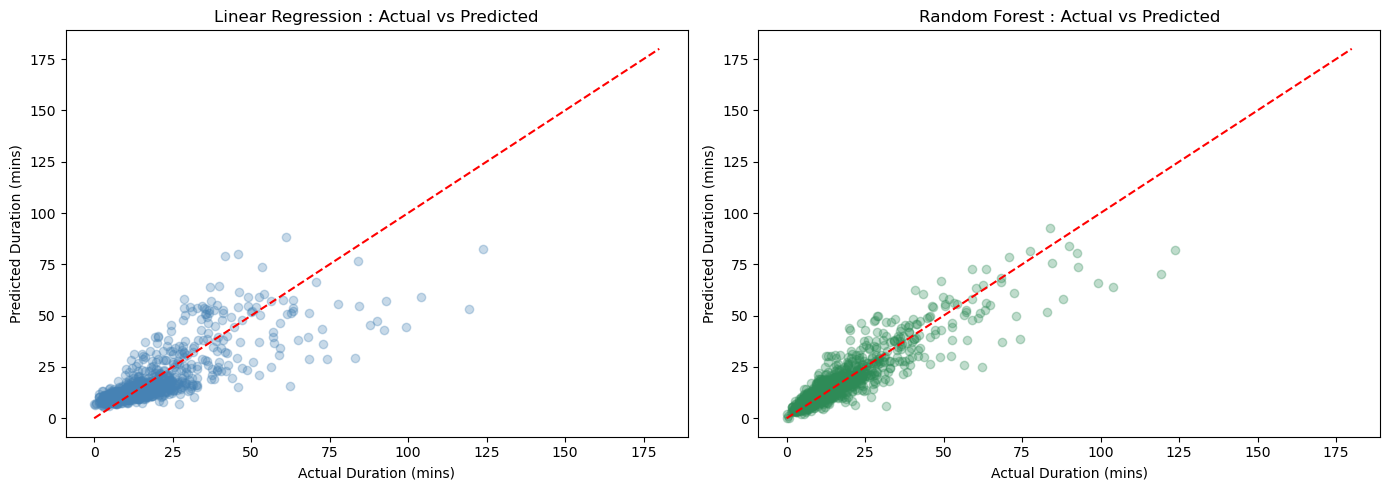

In [48]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

#linear regression - actual vs predicted 
axes[0].scatter(y_test[:1000],y_pred_lr[:1000],alpha=0.3,color='steelblue')
axes[0].plot([0,180],[0,180],'r--')
axes[0].set_xlabel('Actual Duration (mins)')
axes[0].set_ylabel('Predicted Duration (mins)')
axes[0].set_title('Linear Regression : Actual vs Predicted')

#Random forest - actual vs predicted 
axes[1].scatter(y_test[:1000],y_pred_rf[:1000],alpha=0.3,color='seagreen')
axes[1].plot([0,180],[0,180],'r--')
axes[1].set_xlabel('Actual Duration (mins)')
axes[1].set_ylabel('Predicted Duration (mins)')
axes[1].set_title('Random Forest : Actual vs Predicted')

plt.tight_layout()
plt.show()

Feature analysis for both models

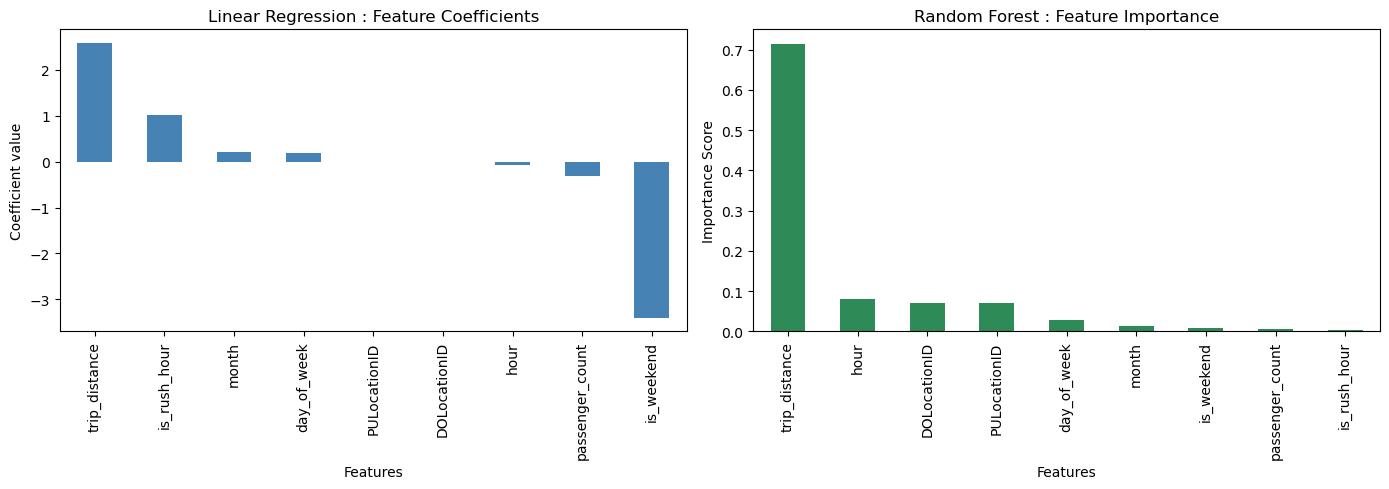

In [51]:
fig,axes = plt.subplots(1,2,figsize=(14,5))

#linear refgression uses coefficients 
lr_coef = pd.Series(lr.coef_,index=features).sort_values(ascending=False)
lr_coef.plot(kind='bar',ax=axes[0],color='steelblue')
axes[0].set_title('Linear Regression : Feature Coefficients')
axes[0].set_xlabel('Features')
axes[0].set_ylabel('Coefficient value')

#random forest - feature importance 
rf_imp = pd.Series(rf.feature_importances_,index=features).sort_values(ascending=False)
rf_imp.plot(kind = 'bar',ax=axes[1],color='seagreen')
axes[1].set_title('Random Forest : Feature Importance')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Importance Score')

plt.tight_layout()
plt.show()

The Random Forest model outperforms Linear Regression baseline across both metrics. This indicates that relationship between trip duration and selected features is non-linear.Trip distance is strongest predictor in both models. Please refer to report for further details.

INSIGHTS , FINDINGS AND DISCUSSION 



Beyond model performance, the pipeline reveals several meaningful patterns in NYC taxi behaviour. Please refer to written report for a full in-depth explanation. 

Temporal Pattern Analysis 

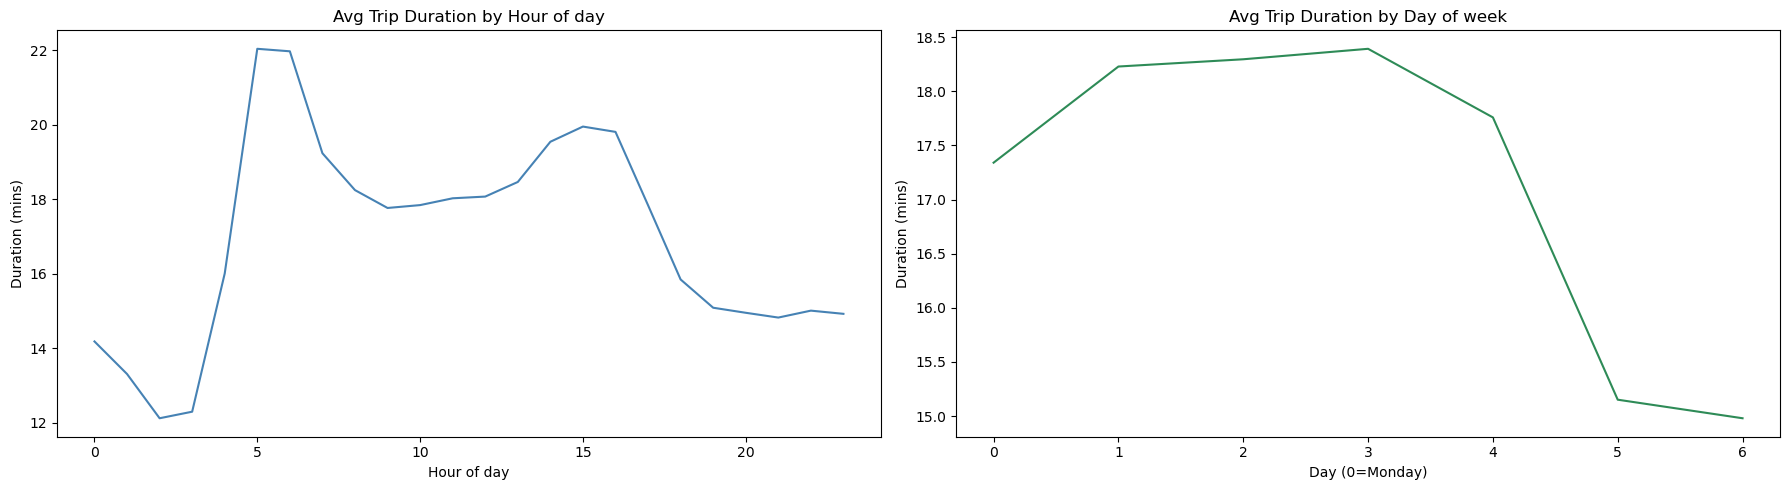

In [67]:
fig, axes = plt.subplots(1,2,figsize=(18,5))

df.groupby('hour')['trip_duration'].mean().plot(ax=axes[0],color='steelblue')
axes[0].set_title('Avg Trip Duration by Hour of day')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Duration (mins)')

df.groupby('day_of_week')['trip_duration'].mean().plot(ax=axes[1],color='seagreen')
axes[1].set_title('Avg Trip Duration by Day of week')
axes[1].set_xlabel('Day (0=Monday)')
axes[1].set_ylabel('Duration (mins)')


plt.tight_layout()
plt.show()

Location effects 

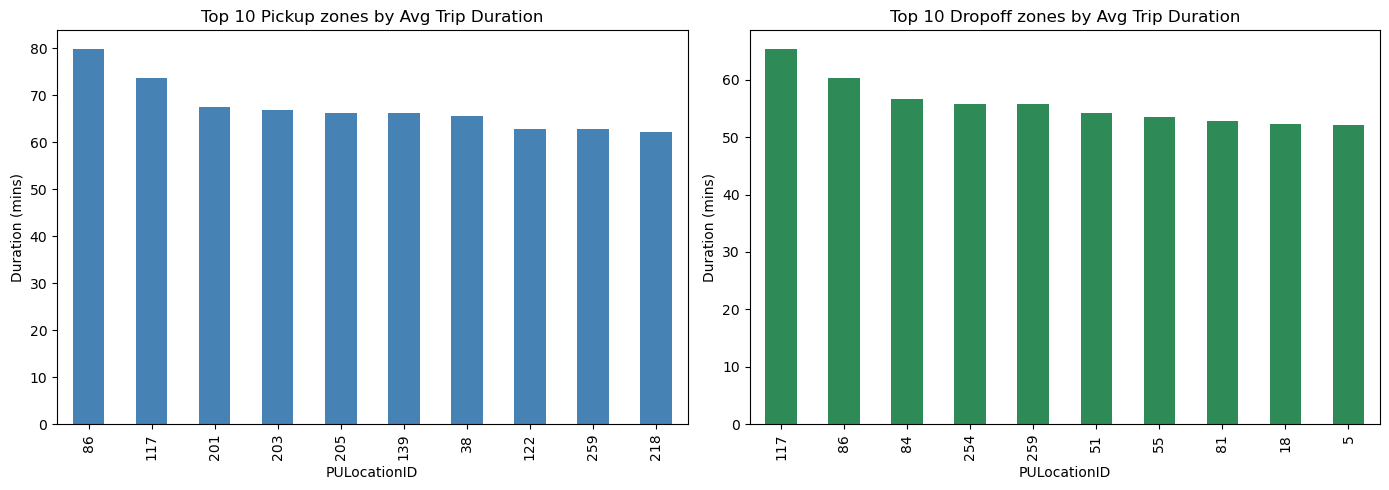

In [70]:
fig,axes = plt.subplots(1,2,figsize=(14,5))

df.groupby('PULocationID')['trip_duration'].mean().sort_values(ascending=False).head(10).plot(kind='bar',ax=axes[0],color='steelblue')
axes[0].set_title('Top 10 Pickup zones by Avg Trip Duration')
axes[0].set_xlabel('PULocationID')
axes[0].set_ylabel('Duration (mins)')

df.groupby('DOLocationID')['trip_duration'].mean().sort_values(ascending=False).head(10).plot(kind='bar',ax=axes[1],color='seagreen')
axes[1].set_title('Top 10 Dropoff zones by Avg Trip Duration')
axes[1].set_xlabel('PULocationID')
axes[1].set_ylabel('Duration (mins)')

plt.tight_layout()
plt.show()

CONCLUSION 

Please refer to the written report thank you. 